In [3]:
#pip install xgboost

In [11]:

# For Data Analysis
import pandas as pd
import numpy as np
# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Data Pre-Processsung
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
# Classifier Libraries
from sklearn.linear_model import SGDClassifier 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier 
from sklearn.svm import LinearSVC, SVC 
from sklearn.naive_bayes import GaussianNB 
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score 
from sklearn.metrics import confusion_matrix
import warnings
warnings. filterwarnings ("ignore")

In [17]:
df = pd.read_csv(r"C:\Users\Lenovo\Documents\10Alytics Data science\diabetes\diabetes_prediction_dataset.csv")

In [19]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [21]:
#get dataframe information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [23]:

df.columns = ['Gender', 'Age', 'Hypertension', 'Heart_Disease', 'Smoking_History', 'BMI', 'Hemoglobin_Alc_Level', 'Blood_Glucose_level', 'Diabetes']

In [25]:
df.columns

Index(['Gender', 'Age', 'Hypertension', 'Heart_Disease', 'Smoking_History',
       'BMI', 'Hemoglobin_Alc_Level', 'Blood_Glucose_level', 'Diabetes'],
      dtype='object')

In [27]:
#get dataframe numerical features
df.describe()

,Age,Hypertension,Heart_Disease,BMI,Hemoglobin_Alc_Level,Blood_Glucose_level,Diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [29]:
#check for missing data
df.isnull().sum()

Gender                  0
Age                     0
Hypertension            0
Heart_Disease           0
Smoking_History         0
BMI                     0
Hemoglobin_Alc_Level    0
Blood_Glucose_level     0
Diabetes                0
dtype: int64

<Axes: >

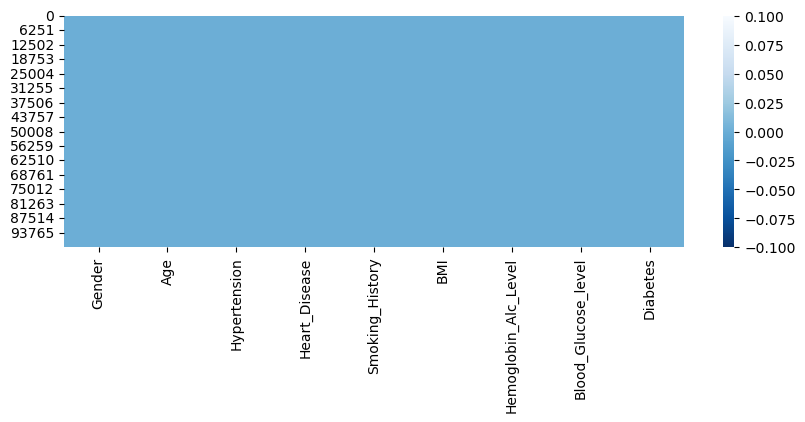

In [31]:
#visualizing the missing data
plt.figure(figsize = (10,3))
sns.heatmap(df.isnull(), cbar=True, cmap="Blues_r")

### Exploratory Data Analysis

#### Univarate Analysis

In [33]:
df.columns

Index(['Gender', 'Age', 'Hypertension', 'Heart_Disease', 'Smoking_History',
       'BMI', 'Hemoglobin_Alc_Level', 'Blood_Glucose_level', 'Diabetes'],
      dtype='object')

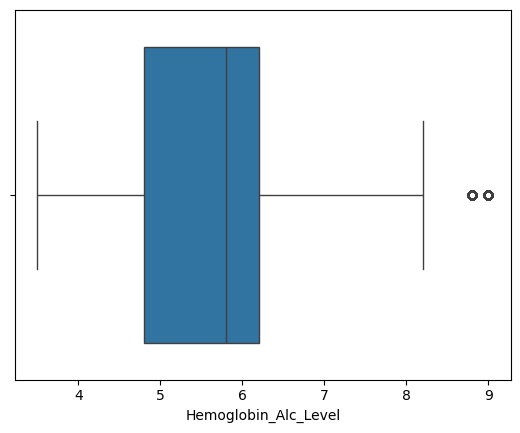

In [35]:
#check for outliers 
sns.boxplot(x=df["Hemoglobin_Alc_Level"]);

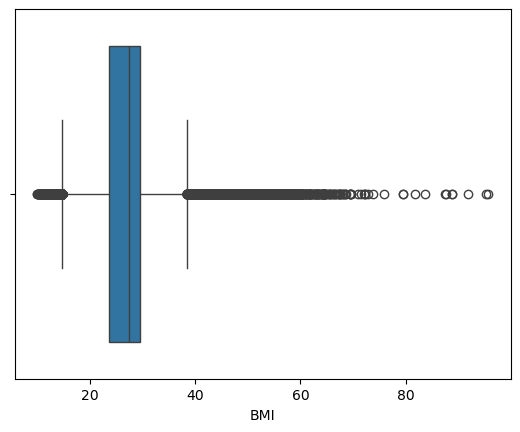

In [37]:
#check for outliers 
sns.boxplot(x=df["BMI"]);

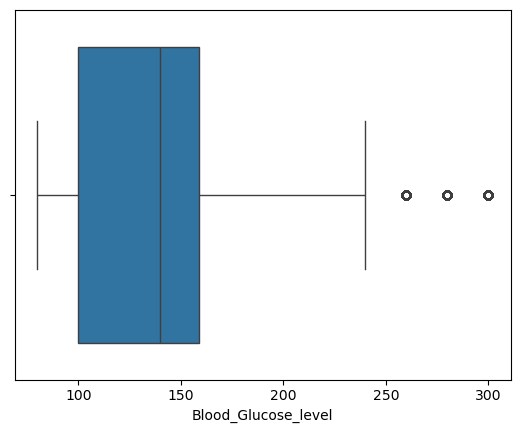

In [39]:

#check for outliers 
sns.boxplot(x=df["Blood_Glucose_level"]);

In [41]:
# Age_bracket
def Age_bracket(Age):
    if Age <= 17:
        return "Minor(<=17)"
    elif Age <= 25 :
        return "Young_Adult(<=25)"
    elif Age <= 55:
        return "Adult(<=55)"
    elif Age <= 65:
        return "Old Adult(<=65)"
    else:
        return "Elderly(>65)"


df['Age_bracket'] = df['Age'].apply(Age_bracket)

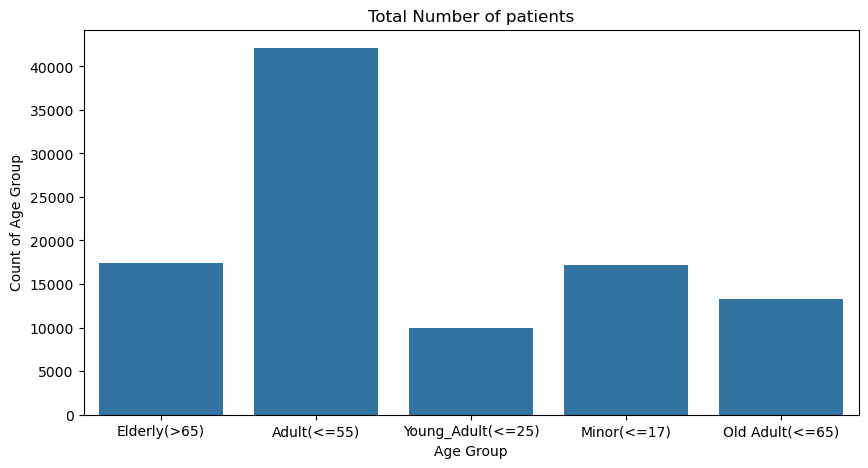

In [43]:
# Investigating the group of patients
plt.figure(figsize = (10, 5))
sns.countplot(x='Age_bracket', data=df)
plt.xlabel('Age Group')
plt.ylabel('Count of Age Group')
plt.title('Total Number of patients');

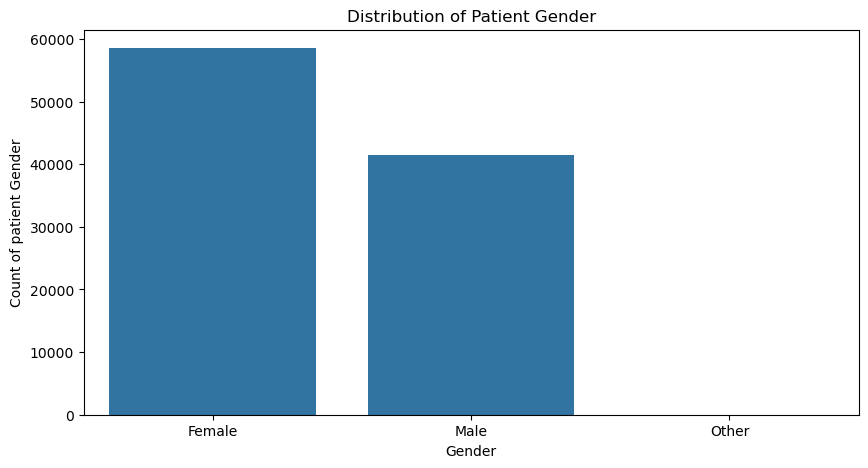

In [45]:
# Data Visualization
# Gender
plt.figure(figsize = (10, 5))
sns.countplot(x='Gender', data=df)
plt.xlabel('Gender')
plt.ylabel('Count of patient Gender') 
plt.title('Distribution of Patient Gender');

### 
Female population is more, from the visualization

In [47]:
df.head()

,Gender,Age,Hypertension,Heart_Disease,Smoking_History,BMI,Hemoglobin_Alc_Level,Blood_Glucose_level,Diabetes,Age_bracket
0,Female,80.0,0,1,never,25.19,6.6,140,0,Elderly(>65)
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,Adult(<=55)
2,Male,28.0,0,0,never,27.32,5.7,158,0,Adult(<=55)
3,Female,36.0,0,0,current,23.45,5.0,155,0,Adult(<=55)
4,Male,76.0,1,1,current,20.14,4.8,155,0,Elderly(>65)


In [51]:
df.drop(columns=['Age_bracket'], inplace=True)

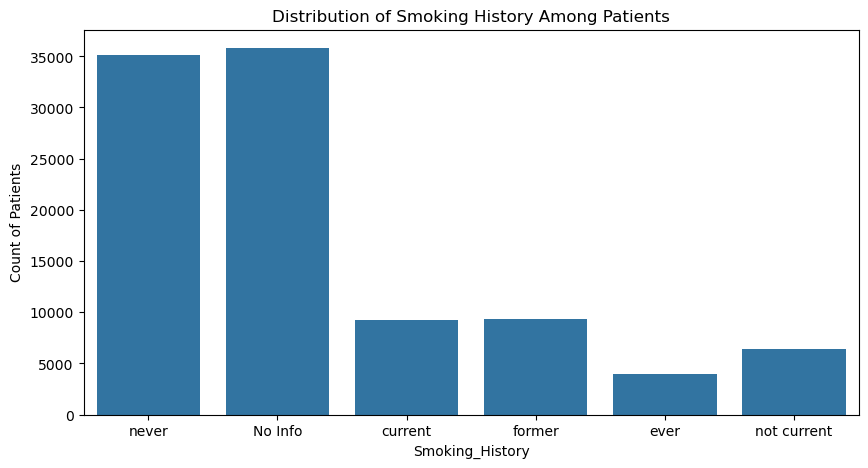

In [53]:
plt.figure(figsize = (10, 5))
sns.countplot(x='Smoking_History', data=df)
plt.xlabel('Smoking_History')
plt.ylabel('Count of Patients') 
plt.title('Distribution of Smoking History Among Patients');

In [55]:
# Data Visualization
# Target has Diabetes or not (1=yes, 0=no)
def label(db):
    if db == 1:
        return "Yes"
    else:
        return "No"


df['Label'] = df['Diabetes'].apply(label)

Text(0.5, 1.0, 'Distribution of Diabetes Among Patients')

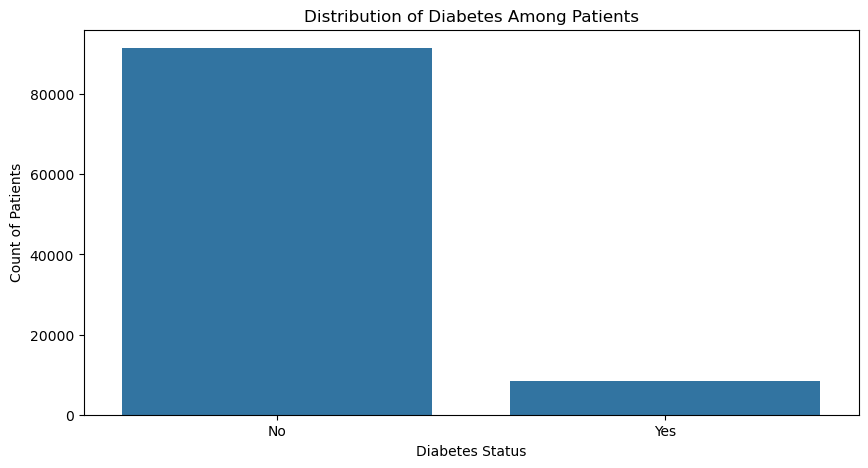

In [57]:
# Investigating the group of patients
plt.figure(figsize = (10, 5))
sns.countplot(x='Label', data=df)
plt.xlabel('Diabetes Status')
plt.ylabel('Count of Patients')
plt.title('Distribution of Diabetes Among Patients')

In [59]:
# Data Visualization
# Patient has Hypertension or not (1=yes, 0=no)
def label_HP(HP):
    if HP == 1:
        return "Yes"
    else:
        return "No"


df['Label_Hypertension'] = df['Hypertension'].apply(label_HP)

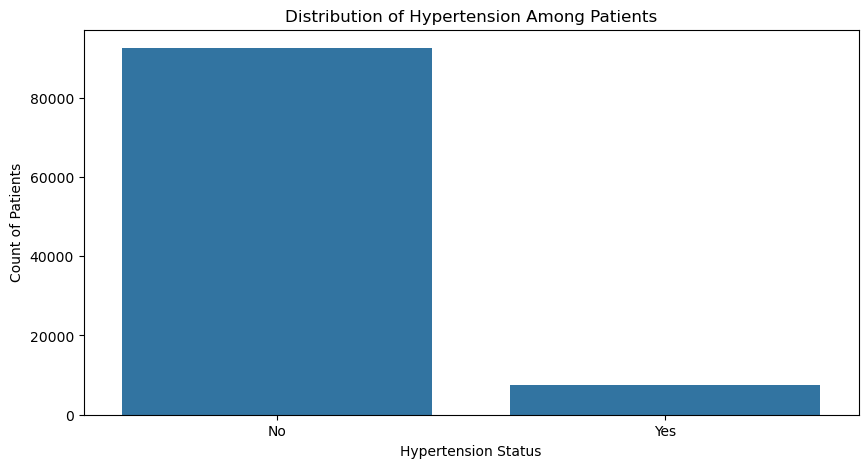

In [61]:
# Investigating the group of patients
plt.figure(figsize = (10, 5))
sns.countplot(x='Label_Hypertension', data=df)
plt.xlabel('Hypertension Status')
plt.ylabel('Count of Patients')
plt.title('Distribution of Hypertension Among Patients');

In [63]:
# Data Visualization
# Patient has Hypertension or not (1=yes, 0=no)
def label_HD(HD):
    if HD == 1:
        return "Yes"
    else:
        return "No"


df['Label_HeartDisease'] = df['Heart_Disease'].apply(label_HD)

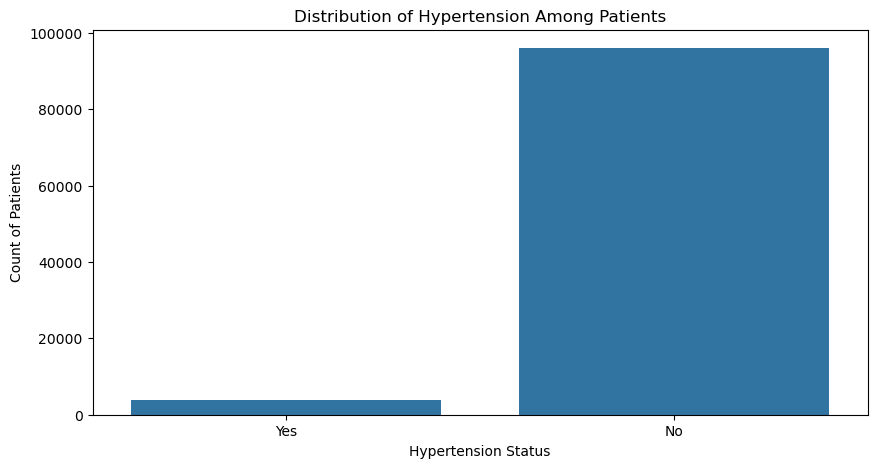

In [65]:
# Investigating the group of patients
plt.figure(figsize = (10, 5))
sns.countplot(x='Label_HeartDisease', data=df)
plt.xlabel('Hypertension Status')
plt.ylabel('Count of Patients')
plt.title('Distribution of Hypertension Among Patients');

## Bivariate Analysis

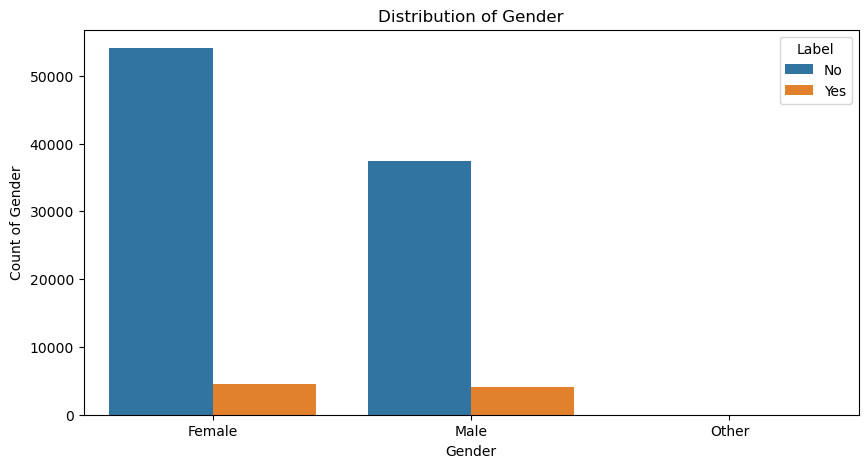

In [67]:
# Investigating the gender of patients by the target feature
plt.figure(figsize = (10, 5))
sns.countplot(x='Gender', data=df, hue='Label')
plt.xlabel('Gender')
plt.ylabel('Count of Gender')
plt.title('Distribution of Gender');

The "Distribution of Gender" column chart above is comparing gender with the label, to find out the kind of patients we have, based on gender. As displayed above, Female has the highest number of 'no' diabetes and male has the least number. Likewise "Yes" to diabetes is higher in females than males.

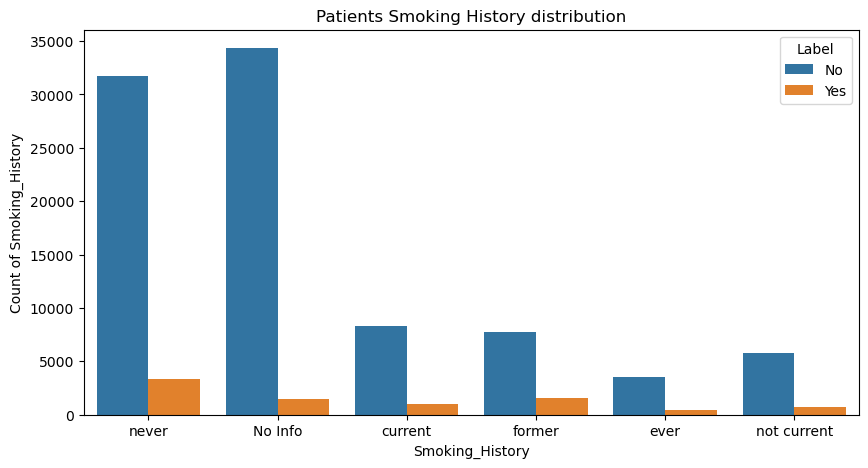

In [69]:
# Investigating the Smoking_History of patients by the target feature
plt.figure(figsize = (10, 5))
sns.countplot(x='Smoking_History', data=df, hue='Label')
plt.xlabel('Smoking_History')
plt.ylabel('Count of Smoking_History')
plt.title('Patients Smoking History distribution');

As seen in the Smoking_History Distribution, patients with "No info" on if they smoke(yes) or not(no) has the highes 'No' on Diabetes, followed by the 'never' smokers. the least is the 'ever' patients.

In [71]:
df['Gender_encoded'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [75]:

print(df.dtypes)

Gender                   object
Age                     float64
Hypertension              int64
Heart_Disease             int64
Smoking_History          object
BMI                     float64
Hemoglobin_Alc_Level    float64
Blood_Glucose_level       int64
Diabetes                  int64
Label                    object
Label_Hypertension       object
Label_HeartDisease       object
Gender_encoded          float64
dtype: object


In [77]:
categorical_data = df.select_dtypes(include="object")
categorical_data.head()

,Gender,Smoking_History,Label,Label_Hypertension,Label_HeartDisease
0,Female,never,No,No,Yes
1,Female,No Info,No,No,No
2,Male,never,No,No,No
3,Female,current,No,No,No
4,Male,current,No,Yes,Yes


## Encode

In [79]:
from sklearn.preprocessing import LabelEncoder

In [81]:
encoder = LabelEncoder()

In [83]:
for column_name in categorical_data:
    print (column_name)

Gender
Smoking_History
Label
Label_Hypertension
Label_HeartDisease


In [85]:
for column_name in categorical_data:
    df[column_name] = encoder.fit_transform(df[column_name])

In [87]:
df.head()

,Gender,Age,Hypertension,Heart_Disease,Smoking_History,BMI,Hemoglobin_Alc_Level,Blood_Glucose_level,Diabetes,Label,Label_Hypertension,Label_HeartDisease,Gender_encoded
0,0,80.0,0,1,4,25.19,6.6,140,0,0,0,1,0.0
1,0,54.0,0,0,0,27.32,6.6,80,0,0,0,0,0.0
2,1,28.0,0,0,4,27.32,5.7,158,0,0,0,0,1.0
3,0,36.0,0,0,1,23.45,5.0,155,0,0,0,0,0.0
4,1,76.0,1,1,1,20.14,4.8,155,0,0,1,1,1.0


### Encoded the categorical data to numerical to be easily read

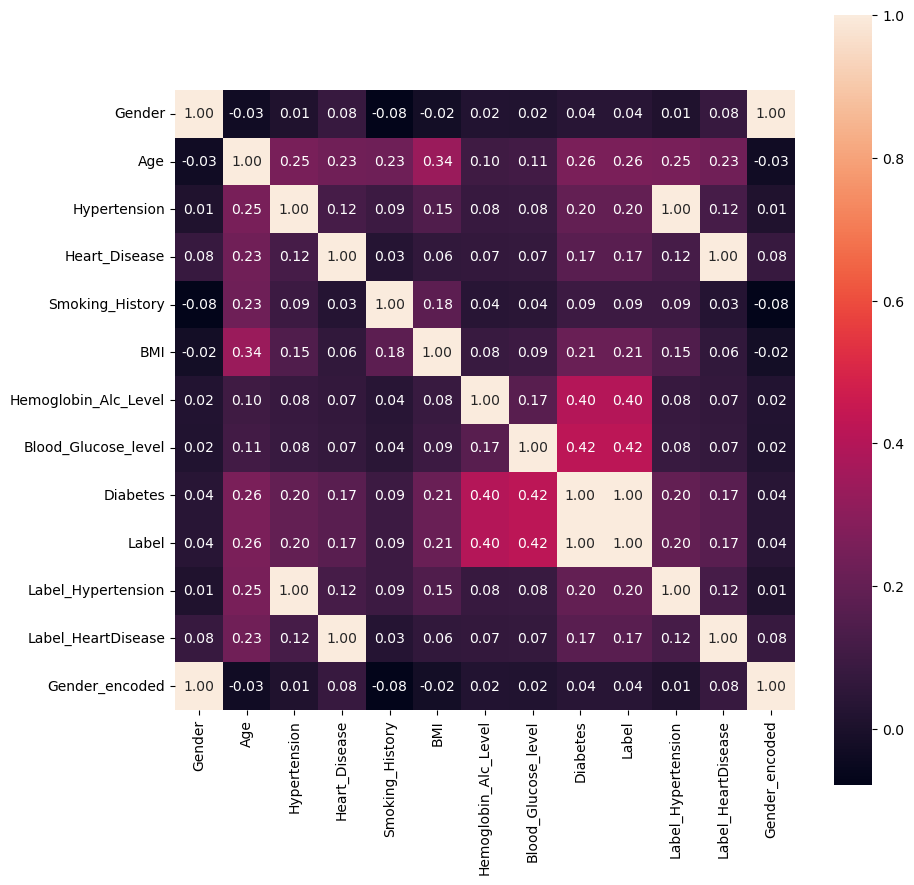

In [89]:
#correlation between Diabetes and other variables in the dataset
plt.figure(figsize = (10, 10))

hm = sns.heatmap(df.corr(), cbar=True, annot=True, square=True, fmt='.2f',
                 annot_kws={'size':10})

In [91]:
# create a copy of the data (exclude diabetes/label alongside other columns that was created)
df1 = df[['Gender','Age', 'Hypertension', 'Heart_Disease', 'Smoking_History', 'BMI', 'Hemoglobin_Alc_Level', 'Blood_Glucose_level']]
label = df[['Diabetes']]

In [93]:
df1.head()

,Gender,Age,Hypertension,Heart_Disease,Smoking_History,BMI,Hemoglobin_Alc_Level,Blood_Glucose_level
0,0,80.0,0,1,4,25.19,6.6,140
1,0,54.0,0,0,0,27.32,6.6,80
2,1,28.0,0,0,4,27.32,5.7,158
3,0,36.0,0,0,1,23.45,5.0,155
4,1,76.0,1,1,1,20.14,4.8,155


In [95]:
label.head()

,Diabetes
0,0
1,0
2,0
3,0
4,0


In [97]:
df1.dtypes

Gender                    int32
Age                     float64
Hypertension              int64
Heart_Disease             int64
Smoking_History           int32
BMI                     float64
Hemoglobin_Alc_Level    float64
Blood_Glucose_level       int64
dtype: object

In [99]:
# Dealing with outliers - 'BMI', 'Hemoglobin', 'Blood_Alc_Level'

#Normalize the data
scaler = MinMaxScaler()

df1["Scaled_BMI"] = scaler.fit_transform(df1[['BMI']].values.reshape(-1, 1))
df1["Scaled_Hemoglobin"] = scaler.fit_transform(df1[['Hemoglobin_Alc_Level']].values.reshape(-1, 1))
df1["Scaled_BGL"] = scaler.fit_transform(df1[['Blood_Glucose_level']].values.reshape(-1, 1))

df1.drop(['BMI', 'Hemoglobin_Alc_Level', 'Blood_Glucose_level'], axis=1, inplace=True)
df1.head()

,Gender,Age,Hypertension,Heart_Disease,Smoking_History,Scaled_BMI,Scaled_Hemoglobin,Scaled_BGL
0,0,80.0,0,1,4,0.177171,0.563636,0.272727
1,0,54.0,0,0,0,0.202031,0.563636,0.000000
2,1,28.0,0,0,4,0.202031,0.400000,0.354545
3,0,36.0,0,0,1,0.156863,0.272727,0.340909
4,1,76.0,1,1,1,0.118231,0.236364,0.340909


In the table above, I dealt with the outliers in BMI, Hemoglobin and Blood Glucose Level by Normalization

## Machine Learning

In [101]:
# split the dataset into training and testing sets - x = Questions, y = Answers
x_train, x_test, y_train, y_test = train_test_split(df1, label, test_size=0.2, random_state=42)

In [103]:
# Model Building
# Logistic Regression

logreg = LogisticRegression()
logreg.fit(x_train, y_train)
ly_pred = logreg.predict(x_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, ly_pred))
print("Precision:", precision_score(y_test, ly_pred))
print("Recall:", recall_score(y_test, ly_pred))
print("F1-score:", f1_score(y_test, ly_pred))
print("AUC-ROC:", roc_auc_score(y_test, ly_pred))

Logistic Regression
Accuracy: 0.958
Precision: 0.8598673300165838
Recall: 0.6071428571428571
F1-score: 0.7117364447494853
AUC-ROC: 0.7989519227765456


Using Logistic Regression, i trained the model and also fed it the answers. It shows the accuracy, precision, recall, f1-score, auc-roc

In [105]:
x_test

,Gender,Age,Hypertension,Heart_Disease,Smoking_History,Scaled_BMI,Scaled_Hemoglobin,Scaled_BGL
75721,0,13.0,0,0,0,0.126167,0.418182,0.209091
80184,0,3.0,0,0,0,0.128268,0.272727,0.295455
19864,1,63.0,0,0,3,0.178688,0.000000,0.545455
76699,0,2.0,0,0,4,0.086601,0.472727,0.209091
92991,0,33.0,0,0,5,0.350957,0.490909,0.545455
...,...,...,...,...,...,...,...,...
32595,0,44.0,0,0,5,0.139356,0.454545,0.359091
29313,1,61.0,1,0,3,0.373133,0.000000,0.045455
37862,0,49.0,0,0,4,0.192577,0.236364,0.090909
53421,1,73.0,0,1,0,0.202031,0.563636,0.090909


In [107]:
print(ly_pred[:10])

[0 0 0 0 0 1 0 0 0 0]


In [109]:
print(y_test[:10])

       Diabetes
75721         0
80184         0
19864         0
76699         0
92991         1
76434         0
84004         0
80917         0
60767         0
50074         0


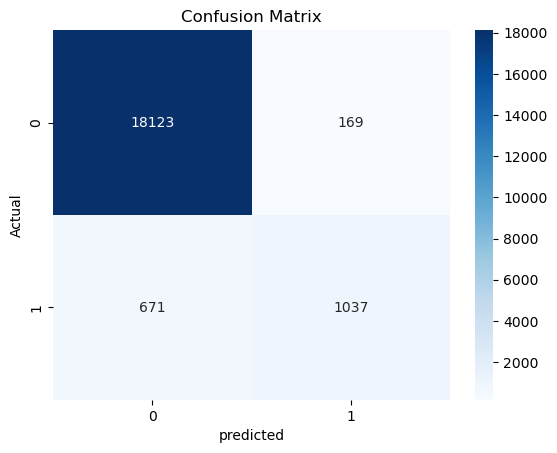

In [111]:
# Create a confusion matrix
lcm = confusion_matrix(y_test, ly_pred)

#Visualize the confusion matrix
sns.heatmap(lcm, annot=True, cmap="Blues", fmt="g")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Heat map of Logistic Regression. Displays the predicted and actual values.

In [113]:
# Model Building
# Random Forest Classifier
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)
rfy_pred = rfc.predict(x_test) 
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, rfy_pred))
print("Precision:", precision_score(y_test, rfy_pred))
print("Recall:", recall_score(y_test, rfy_pred))
print("F1-score:", f1_score(y_test, rfy_pred))
print("AUC-ROC:", roc_auc_score(y_test, rfy_pred))

Logistic Regression
Accuracy: 0.9699
Precision: 0.9474110032362459
Recall: 0.6855971896955504
F1-score: 0.795516304347826
AUC-ROC: 0.8410218618497433


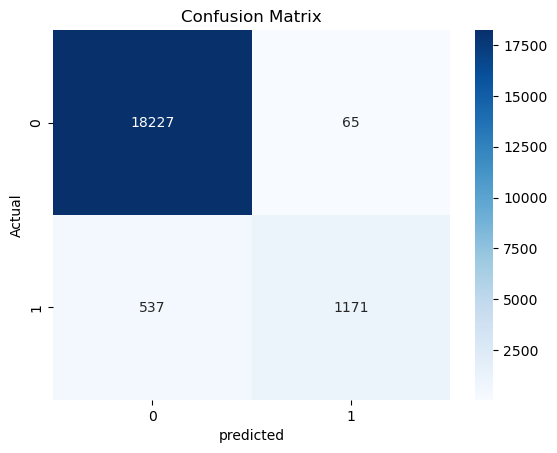

In [115]:
rcm = confusion_matrix(y_test, rfy_pred)

#Visualize the confusion matrix
sns.heatmap(rcm, annot=True, cmap="Blues", fmt="g")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [117]:
# Using for loop to loop through the classifiers
classifiers = [[XGBClassifier(), 'XGB Classifier'],
               [RandomForestClassifier(), 'Random Forest'],
               [KNeighborsClassifier(), 'K-Nearest Classifier'],
               [SGDClassifier(), 'SGDC Classifier'],
               [SVC(), 'SVC'],
               [GaussianNB(), 'Naive Rayes'],
               [DecisionTreeClassifier(random_state = 42), "Decision tree"],
               [LogisticRegression(), "Logistic Regression"]
              ]  

In [119]:
classifiers

[[XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_estimators=None,
                n_jobs=None, num_parallel_tree=None, ...),
  'XGB Classifier'],
 [RandomForestClassifier(), 'Random Forest'],
 [KNeighborsClassifier(), 'K-Nearest Classifier'],
 [SGDClassifier(), 'SGDC Classifier'],
 [SVC(), 'SVC'],
 [GaussianNB(), 'Naive Rayes'],
 [Decision

In [121]:
# Loop through multiple models
acc_list = {}
precision_list = {}
recall_list = {}
roc_list = {}

for classifier in classifiers:
    model = classifier[0]
    model.fit(x_train, y_train)
    model_name = classifier[1]

    pred = model.predict(x_test)

    a_score = accuracy_score(y_test, pred)
    p_score = precision_score(y_test, pred)
    r_score = recall_score(y_test, pred)
    p_score = roc_auc_score(y_test, pred)

    acc_list[model_name] = ([str(round(a_score*100, 2)) + '%'])
    precision_list[model_name] = ([str(round(p_score*100, 2)) + '%'])
    recall_list[model_name] = ([str(round(r_score*100, 2)) + '%'])
    roc_list[model_name] = ([str(round(r_score*100, 2)) + '%'])

    if model_name != classifiers[-1][1]:
        print('')
    

In [122]:
# accuracy
acc_list

{'XGB Classifier': ['97.1%'],
 'Random Forest': ['97.0%'],
 'K-Nearest Classifier': ['93.95%'],
 'SGDC Classifier': ['95.23%'],
 'SVC': ['91.48%'],
 'Naive Rayes': ['90.48%'],
 'Decision tree': ['95.22%'],
 'Logistic Regression': ['95.8%']}

In [125]:
print("Precision")
s2 = pd.DataFrame(precision_list)
s2.head()

Precision


,XGB Classifier,Random Forest,K-Nearest Classifier,SGDC Classifier,SVC,Naive Rayes,Decision tree,Logistic Regression
0,84.56%,84.27%,68.03%,82.05%,50.12%,78.39%,85.52%,79.9%


In [127]:
print("Recall")
s3 = pd.DataFrame(recall_list)
s3.head()

Recall


,XGB Classifier,Random Forest,K-Nearest Classifier,SGDC Classifier,SVC,Naive Rayes,Decision tree,Logistic Regression
0,69.44%,68.91%,36.77%,66.16%,0.23%,63.82%,73.83%,60.71%


In [129]:
print("Roc score")
s4 = pd.DataFrame(roc_list)
s4.head()

Roc score


,XGB Classifier,Random Forest,K-Nearest Classifier,SGDC Classifier,SVC,Naive Rayes,Decision tree,Logistic Regression
0,69.44%,68.91%,36.77%,66.16%,0.23%,63.82%,73.83%,60.71%



Rather than go through each classifier one by one, i'll put them in a for loop to make the whole process efficient.

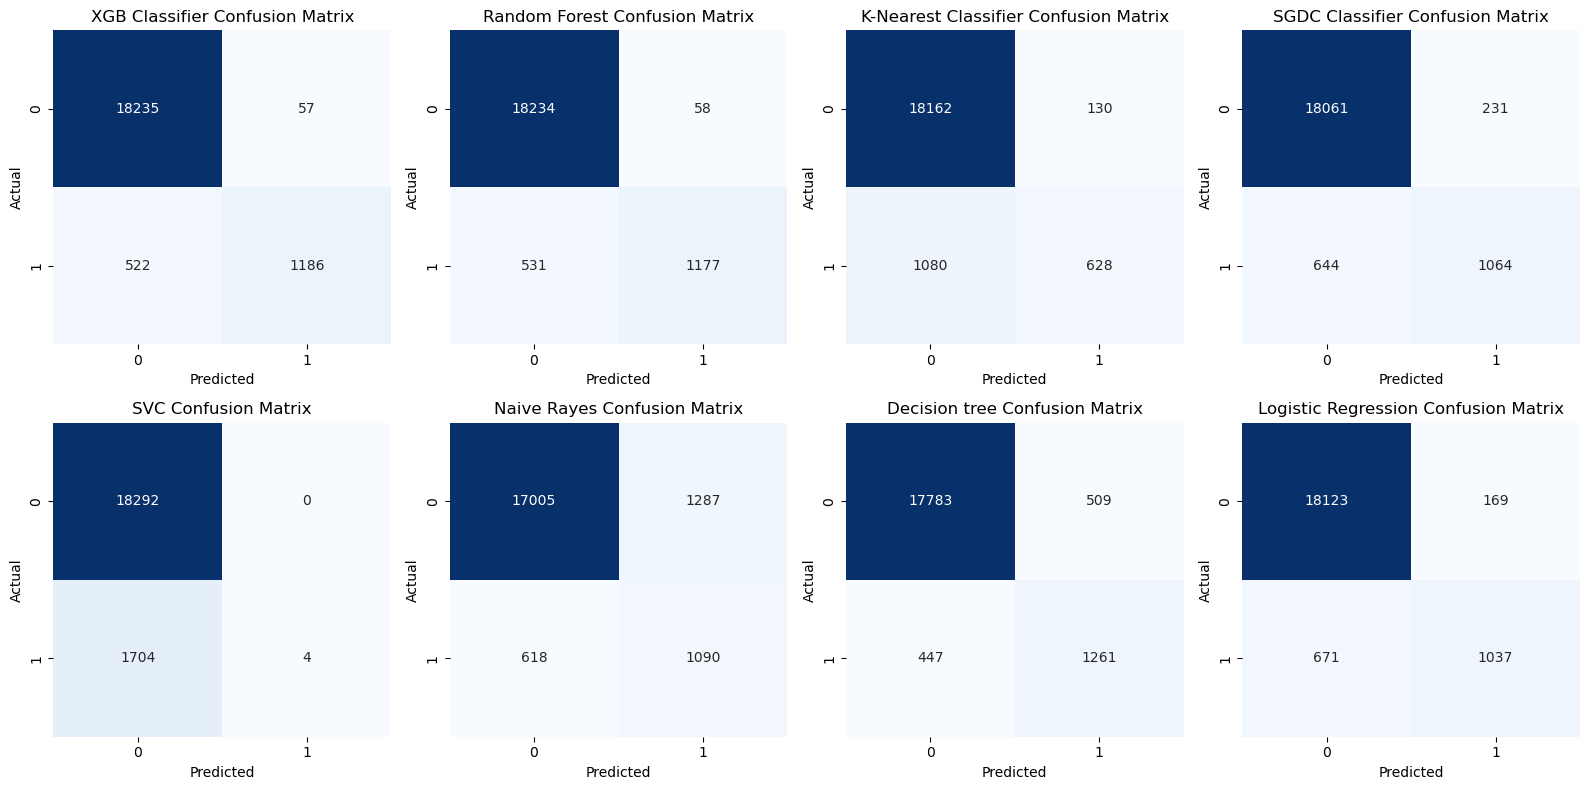

                      Accuracy  Precision  Recall  ROC AUC
XGB Classifier           97.10      95.41   69.44    84.56
Random Forest            97.06      95.30   68.91    84.30
K-Nearest Classifier     93.95      82.85   36.77    68.03
SGDC Classifier          95.62      82.16   62.30    80.52
SVC                      91.48     100.00    0.23    50.12
Naive Rayes              90.48      45.86   63.82    78.39
Decision tree            95.22      71.24   73.83    85.52
Logistic Regression      95.80      85.99   60.71    79.90


In [131]:
# Initialize lists to store the scores
acc_list = {}
precision_list = {}
recall_list = {}
roc_list = {}

# Initialize the plot for confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(16, 8))  # Adjust the layout based on number of classifiers
axes = axes.flatten()  # Flatten the 2D array to make indexing easier

# Loop through the classifiers
for idx, classifier in enumerate(classifiers):
    model = classifier[0]
    model_name = classifier[1]

    # Train the model
    model.fit(x_train, y_train)
    
    # Make predictions
    pred = model.predict(x_test)

    # Calculate performance metrics
    a_score = accuracy_score(y_test, pred)
    p_score = precision_score(y_test, pred)
    r_score = recall_score(y_test, pred)
    roc_score = roc_auc_score(y_test, pred)

    # Store metrics in dictionaries
    acc_list[model_name] = round(a_score * 100, 2)
    precision_list[model_name] = round(p_score * 100, 2)
    recall_list[model_name] = round(r_score * 100, 2)
    roc_list[model_name] = round(roc_score * 100, 2)

    # Plot the confusion matrix
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[idx]), 

    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

    
    axes[idx].set_title(f"{model_name} Confusion Matrix")

# Adjust layout for better visualization
plt.tight_layout()
plt.show()

# Create a DataFrame with the results
results_df = pd.DataFrame({
    'Accuracy': acc_list,
    'Precision': precision_list,
    'Recall': recall_list,
    'ROC AUC': roc_list
})

# Print the results DataFrame
print(results_df)

## Conclusion

Based on the evaluation of the models, the following insights were drawn for patients diabetes prediction:

Accuracy: The model with the highest accuracy is XGB Classifier, indicating it correctly predicts the most instances.

Precision: XGB Classifier also achieved the best precision, minimizing false positives.

Recall: XGB Classifier performed best in recall, effectively identifying true positives.

ROC AUC: XGB Classifier also led in ROC AUC, showing the best balance between sensitivity and specificity.

Overall, XGB Classifier is the most reliable model for this dataset based on these metrics.Based on the evaluation of the models, the following insights were drawn for patients diabetes prediction:

Accuracy: The model with the highest accuracy is XGB Classifier, indicating it correctly predicts the most instances.

Precision: XGB Classifier also achieved the best precision, minimizing false positives.

Recall: XGB Classifier performed best in recall, effectively identifying true positives.

ROC AUC: XGB Classifier also led in ROC AUC, showing the best balance between sensitivity and specificity.

Overall, XGB Classifier is the most reliable model for this dataset based on these metrics.